<a href="https://colab.research.google.com/github/stephenebert/Springboard/blob/main/Mini_Project_More_Experience_With_Machine_Learning_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1

In [2]:
!pip install scikeras

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from keras.models import Sequential
from keras.layers import Dense
from scikeras.wrappers import KerasClassifier
from sklearn.pipeline import Pipeline

**1. Load the Adult data into a Pandas Dataframe.**

In [4]:
DATA_PATH = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
df = pd.read_csv(DATA_PATH)

In [5]:
df

,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
0,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
1,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
2,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
3,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
4,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32555,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32556,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32557,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32558,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


**2. Ensure the dataset has properly named columns. If the columns are not read in, assign them by referencing the dataset documentation.**

In [6]:
column_names = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

df = pd.read_csv(
    DATA_PATH,
    names=column_names,
    skipinitialspace=True,
    na_values='?'
)


In [7]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


**3. Display the first five rows of the dataset.**

In [8]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [9]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [10]:
df.isna().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


In [11]:
print("Any gain:", (df['capital-gain'] > 0).mean())

print("Any loss:", (df['capital-loss'] > 0).mean())

print(df['capital-gain'].value_counts().head())
print(df['capital-loss'].value_counts().head())


Any gain: 0.08328982525106723
Any loss: 0.0466509013850926
capital-gain
0        29849
15024      347
7688       284
7298       246
99999      159
Name: count, dtype: int64
capital-loss
0       31042
1902      202
1977      168
1887      159
1485       51
Name: count, dtype: int64


# Part 2

**1. Do exploratory data analysis to give you some better intuition for the dataset. This is a bit open-ended. How many rows/columns are there? How are NULL values represented? What's the percentage of positive cases in the dataset?**

In [12]:
# rows / columns?
print(f"Dataset shape: {df.shape[0]:} rows x {df.shape[1]} columns")

# NULLs represented?
print("\nMissing values per column:")
print(df.isnull().sum())

# Percentage of positive cases
pct_positive = (df['income'] == '>50K').mean() * 100 # mean = number of positives / total number of cases
print(f"\n% of people earning >50K: {pct_positive:.2f}%")

Dataset shape: 32561 rows x 15 columns

Missing values per column:
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

% of people earning >50K: 24.08%


**2. Drop all rows with NULL values.**

In [13]:
df = df.dropna()
df.shape

(30162, 15)

**3. Use Scikit-Learn's LabelEncoder to convert the income column with a data type string to a binary variable.**

In [17]:
df = df.dropna().copy()

le = LabelEncoder()

df['income_binary'] = le.fit_transform(df['income'])

print("Classes:", le.classes_)
print(df['income_binary'].value_counts())


Classes: ['<=50K' '>50K']
income_binary
0    22654
1     7508
Name: count, dtype: int64


In [18]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,income_binary
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K,0
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K,1
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K,0
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K,0


# Part 3

**1. Split the data into training and test sets. Remember not to include the label you're trying to predict, income, as a column in your training data.**

In [20]:
X = df.drop(['income', 'income_binary'], axis=1)
y = df['income_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test : {X_test.shape}, y_test : {y_test.shape}")

X_train: (24129, 14), y_train: (24129,)
X_test : (6033, 14), y_test : (6033,)


# Part 4

**1. Use Scikit-Learn's roc_auc_score to calculate the AUC score for a method that always predicts the majority class.**

In [27]:
from sklearn.metrics import roc_auc_score
positive_rate = y_train.mean()
print(f"Positive rate: {positive_rate:.5f}")

y_scores_majority = np.full(shape = y_test.shape, fill_value = positive_rate, dtype = float)

auc_majority = roc_auc_score(y_test, y_scores_majority)

print(f"Majority‐class AUC: {auc_majority:.5f}")

Positive rate: 0.24775
Majority‐class AUC: 0.50000


np.full() method creates a new array of a given shape and fills every element with the same constant value. We need this because roc_auc_score demands a vector of scores or probabilities for each test sample. roc_auc_score(y_true, y_score) computes the true positive rate ( TPR = # true positives / # actual positives) and the false positive rate (FPR = # false positive / # actual negatives)

$$ \text{AUC} = \sum^{n-1}_{i=1} \frac{\left( \text{FPR}_{i+1} - \text{FPR}_i \right) \left( \text{TPR}_{i+1} - \text{TPR}_i \right)}{2} $$

after computing the pairs (FPR, TPR) for the AUC

# Part 5

**1. Use Scikit-Learn's ColumnTransformer to apply One Hot Encoding to the categorical variables in workclass, education, marital-status, occupation, relationship, 'race', sex, and native-country. Also, apply MinMaxScaler to the remaining continuous features. How many columns will the dataframe have after these columns transformations are applied?**

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

categorical_cols = [
    'workclass', 'education', 'marital-status', 'occupation',
    'relationship', 'race', 'sex', 'native-country'
]
continuous_cols = [
    'age', 'fnlwgt', 'education-num',
    'capital-gain', 'capital-loss', 'hours-per-week'
]

# transformer
preprocessor = ColumnTransformer([
    (
        'cat_ohe',
        OneHotEncoder(handle_unknown='ignore', sparse_output=False),
        categorical_cols
    ),
    (
        'num_mm',
        MinMaxScaler(),
        continuous_cols
    ),
], remainder='drop')

# Fit + transform on the training set
X_train_transformed = preprocessor.fit_transform(X_train)

n_columns = X_train_transformed.shape[1]
print(f"Number of columns after transformation: {n_columns}")


Number of columns after transformation: 104


# Part 6

**1. Create your own model in Keras to predict income in the Adult training data. Remember, it's always better to start simple and add complexity to the model if necessary. What's a good loss function to use?**

In [34]:
input_dim = X_train_transformed.shape[1]

model = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['AUC']
)

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         6,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,833 (34.50 KB)

 Non-trainable params: 0 (0.00 B)

We begin with two small hidden layers 64 -> 32 units using activation = 'relu' and a single-unit sigmoid output. The loss function is binary_crossentropy is the usual choice when we have a sigmoid output for a 0/1 target.



**2. Keras can be integrated with Scitkit-Learn using a wrapper. Use the KerasClassifier wrapper to integrate your Keras model with the ColumnTransformer from previous steps using a Pipeline object.**

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
     ['workclass','education','marital-status','occupation',
      'relationship','race','sex','native-country']),
    ('mm',  MinMaxScaler(),
     ['age','fnlwgt','education-num','capital-gain',
      'capital-loss','hours-per-week'])
], remainder='drop')

def build_model(input_dim: int):
    m = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dense(32, activation='relu'),
        Dense(1,  activation='sigmoid')
    ])
    m.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['AUC'])
    return m

X_train_pre = preprocessor.fit_transform(X_train)
n_features = X_train_pre.shape[1]

keras_clf = KerasClassifier(
    model=build_model,
    model__input_dim=n_features,
    epochs=10,
    batch_size=32,
    verbose=1
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',   keras_clf)
])

pipeline.fit(X_train, y_train)

X_test_pre  = pipeline.named_steps['preprocessor'].transform(X_test)
y_proba = pipeline.named_steps['classifier'].predict_proba(X_test_pre).ravel()

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


755/755 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - AUC: 0.8300 - loss: 0.4137
Epoch 2/10
755/755 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.8945 - loss: 0.3419
Epoch 3/10
755/755 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.9036 - loss: 0.3277
Epoch 4/10
755/755 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.9074 - loss: 0.3235
Epoch 5/10
755/755 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.9106 - loss: 0.3160
Epoch 6/10
755/755 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AUC: 0.9128 - loss: 0.3111
Epoch 7/10
755/755 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AUC: 0.9166 - loss: 0.3070
Epoch 8/10
755/755 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.9123 - loss: 0.3148
Epoch 9/10
755/755 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.9168 - loss: 0.3049
Epoch 10/10
755/755 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - AUC: 0.9157 - loss: 0.3089
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


**3. Fit your model.**

In [52]:
pipeline.fit(X_train, y_train);

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


755/755 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - AUC: 0.8111 - loss: 0.4304
Epoch 2/10
755/755 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.8939 - loss: 0.3448
Epoch 3/10
755/755 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.8981 - loss: 0.3344
Epoch 4/10
755/755 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - AUC: 0.9065 - loss: 0.3237
Epoch 5/10
755/755 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.9119 - loss: 0.3142
Epoch 6/10
755/755 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.9072 - loss: 0.3189
Epoch 7/10
755/755 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.9113 - loss: 0.3161
Epoch 8/10
755/755 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - AUC: 0.9174 - loss: 0.3062
Epoch 9/10
755/755 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - AUC: 0.9185 - loss: 0.3027
Epoch 10/10
755/755 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - AUC: 0.9183 - loss: 0.3041


**4. Calculate the AUC score of your model on the test data. Does the model predict better than random?**

In [51]:
from sklearn.metrics import roc_auc_score

X_test_pre = pipeline.named_steps['preprocessor'].transform(X_test)

y_proba_all = pipeline.named_steps['classifier'].predict_proba(X_test_pre)

y_proba = y_proba_all[:, 1]

auc = roc_auc_score(y_test, y_proba)
print(f"Test AUC: {auc:.5f}")

if auc > 0.5:
    print("The model predicts better than random guessing.")
else:
    print("The model does not perform better than random guessing.")


189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Test AUC: 0.90790
The model predicts better than random guessing.


**5. Generate an ROC curve for your model using RocCurveDisplay. What would the curve look like if all your predictions were randomly generated? What would the curve look like if it you had a perfect model?**

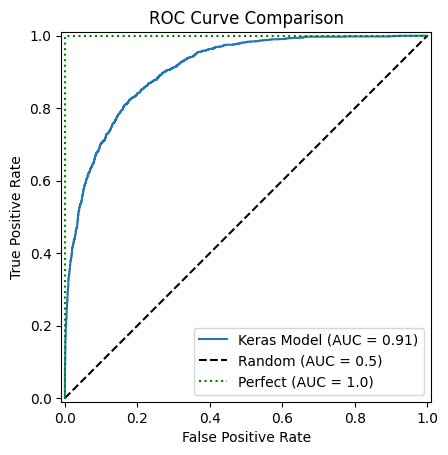

In [53]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

disp = RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    name='Keras Model'
)

# Overlay the random classifier (diagonal line at 45 degrees)
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')

# Overlay the perfect classifier (goes straight up then right over)
plt.plot([0, 0, 1], [0, 1, 1], 'g:', label='Perfect (AUC = 1.0)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()


A model that guesses completely at random would have an ROC curve following a straight diagonal line from the bottom-left (0,0) to the top-right corner (1,1). This means the true-positive rate (TPR) and false-positive rate (FPR) would always be equal, indicating the model provides no meaningful separation between positive and negative examples. Such a model has an AUC of exactly 0.5.

A perfect classifier immediately achieves a true-positive rate of 100% before registering any false positives. Its ROC curve rises vertically from (0,0) directly up to (0,1) and then moves horizontally rightward to (1,1). This demonstrates flawless discrimination between classes, yielding an AUC of 1.0.